In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
df=pd.read_csv('car data.csv')

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [7]:
df.columns=df.columns.str.strip()

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool

In [19]:
# 3. Remove duplicate rows

In [11]:
df=df.drop_duplicates()

In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [13]:
df.shape

(299, 9)

In [20]:
# 4. Remove extra spaces from text columns

In [15]:
for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].str.strip()

C:\Users\Arati\AppData\Local\Temp\ipykernel_25576\2305082259.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [16]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [21]:
# 5. Convert numerical columns into numeric format

In [17]:
numerical_cols=['Year','Selling_Price','Present_Price','Kms_Driven','Owner']

In [26]:
for col in numerical_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')

In [22]:
# 6. Remove bike entries from the dataset

# Your dataset contains some bikes also.
# These names are excluded to keep only cars.
bike_keywords = [
    "royal enfield",
    "ktm",
    "bajaj",
    "yamaha",
    "tvs",
    "hero",
    "honda cb",
    "honda cbr",
    "honda activa",
    "honda dream",
    "honda hornet",
    "honda unicorn",
    "honda shine",
    "honda twister",
    "honda karizma",
    "honda trigger",
    "hyosung",
    "um renegade",
    "mahindra mojo"
]

df["Car_Name"] = df["Car_Name"].astype(str).str.strip()

bike_mask = df["Car_Name"].str.lower().apply(
    lambda name: any(word in name for word in bike_keywords)
)

df = df[~bike_mask].copy()

print("\nDataset after removing bikes:", df.shape)





Dataset after removing bikes: (202, 9)


In [27]:
# 7. Handle missing values

# Remove rows where target is missing

df = df.dropna(subset=["Selling_Price"])

# Fill missing numerical values

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values

categorical_cols = [
    "Car_Name",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])




In [28]:
# 8. Remove invalid values

df = df[
    (df["Year"] > 0) &
    (df["Selling_Price"] > 0) &
    (df["Present_Price"] > 0) &
    (df["Kms_Driven"] >= 0)
].copy()


In [29]:
# 9. Feature Engineering

# Feature 1: Car Age

df["Car_Age"] = 2026 - df["Year"]

# Feature 2: Kilometers per Year

df["Kms_Per_Year"] = df["Kms_Driven"] / df["Car_Age"].clip(lower=1)

# Feature 3: Price Difference

df["Price_Difference"] = df["Present_Price"] - df["Selling_Price"]


print("\nNew Features Created:")
print(df[[
    "Car_Age",
    "Kms_Per_Year",
    "Price_Difference"
]].head())



New Features Created:
   Car_Age  Kms_Per_Year  Price_Difference
0       12   2250.000000              2.24
1       13   3307.692308              4.79
2        9    766.666667              2.60
3       15    346.666667              1.30
4       12   3537.500000              2.27


In [30]:
# 10. Remove leakage columns

# Selling_Price is our target.
# Price_Difference also uses Selling_Price,
# so it must NOT be used as an input feature.

# Year is removed because Car_Age is already available.


In [31]:
# 11. Prepare X and y

X = df.drop(
    columns=[
        "Selling_Price",
        "Price_Difference",
        "Year"
    ]
)

y = df["Selling_Price"]

In [32]:
X.shape

(202, 9)

In [33]:
y.shape

(202,)

In [43]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [44]:
# ============================================================
# WEEK 4: MODEL TRAINING
# ============================================================

# 12. Separate numerical and categorical features

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()


C:\Users\Arati\AppData\Local\Temp\ipykernel_25576\3208957740.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [45]:
# 13. Preprocessing

# Numerical missing values are filled using median

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])


# Categorical missing values are filled using most frequent

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Training Data: (161, 9)
Testing Data: (41, 9)

Model Training Completed!

========== MODEL EVALUATION ==========
MAE in Rupees: ₹ 91683.17
RMSE in Rupees: ₹ 138864.78
R2 Score: 0.8981

========== TOP 5 IMPORTANT FEATURES ==========
                   Feature  Importance
0       num__Present_Price    0.852111
3             num__Car_Age    0.086402
1          num__Kms_Driven    0.015502
4        num__Kms_Per_Year    0.011796
26  cat__Car_Name_fortuner    0.005821


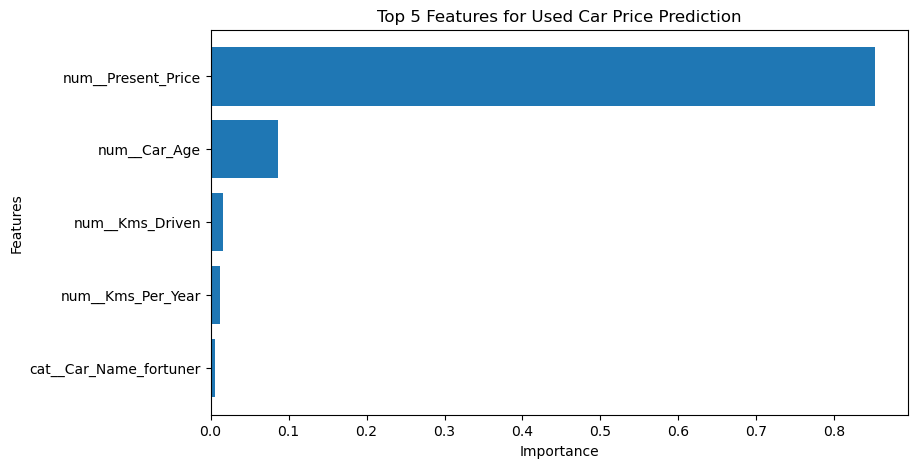


========== NEW CAR PREDICTION ==========
Car Name: Honda City
Predicted Selling Price: ₹ 807355.0

PROJECT COMPLETED SUCCESSFULLY!


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# 15. Create Random Forest Model

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None
    ))
])


# 16. Train Model

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# 17. Prediction on Test Data

y_pred = model.predict(X_test)


# 18. Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

# Prices are stored in Lakhs.
# Multiply by 100000 to get actual rupees.

print("MAE in Rupees: ₹", round(mae * 100000, 2))

print("RMSE in Rupees: ₹", round(rmse * 100000, 2))

print("R2 Score:", round(r2, 4))


# 19. Feature Importance

# Get feature names after OneHotEncoding

encoded_features = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = model.named_steps[
    "regressor"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importance
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== TOP 5 IMPORTANT FEATURES ==========")

print(feature_importance.head(5))


# 20. Feature Importance Graph

top5 = feature_importance.head(5)

plt.figure(figsize=(9, 5))

plt.barh(
    top5["Feature"],
    top5["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Top 5 Features for Used Car Price Prediction")

plt.gca().invert_yaxis()

plt.show()


# ============================================================
# 21. PREDICT PRICE OF A NEW CAR
# ============================================================

# Example of a new car

new_car = pd.DataFrame([{
    "Car_Name": "city",
    "Present_Price": 10.0,
    "Kms_Driven": 25000,
    "Fuel_Type": "Petrol",
    "Seller_Type": "Dealer",
    "Transmission": "Manual",
    "Owner": 0,
    "Car_Age": 4,
    "Kms_Per_Year": 6250
}])


# Predict price

predicted_price = model.predict(new_car)[0]

print("\n========== NEW CAR PREDICTION ==========")

print("Car Name: Honda City")

print("Predicted Selling Price: ₹",
      round(predicted_price * 100000, 2))

print("\nPROJECT COMPLETED SUCCESSFULLY!")
